In [162]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split,StratifiedKFold,cross_val_score
from sklearn.metrics import accuracy_score,classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# We do classification bcoz the output is like 5,6,7 it is not a continous value we can also do it as regression but when we get output like 5.8 we have to round it to 6 this rounding up of data can add extra processing and can introduce small error so, it is better to use classification here 

In [163]:
df=pd.read_csv("WineQT.csv")  
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [164]:
df.isnull().sum() # we got all as 0 so there are no missing values in our dataset
df=df.drop("Id",axis=1,errors="ignore") # Id dont contribute so we are droping it. here errors=ignore means if we already deleted this then the code dont crash and it dont give any error like id not exist in the dataset.
df.head() # Now we have dropped the id column

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [165]:

y=df["quality"] # ouput
x=df.drop(columns=["quality"]) #input
df.shape

                                                                                                             

(1143, 12)

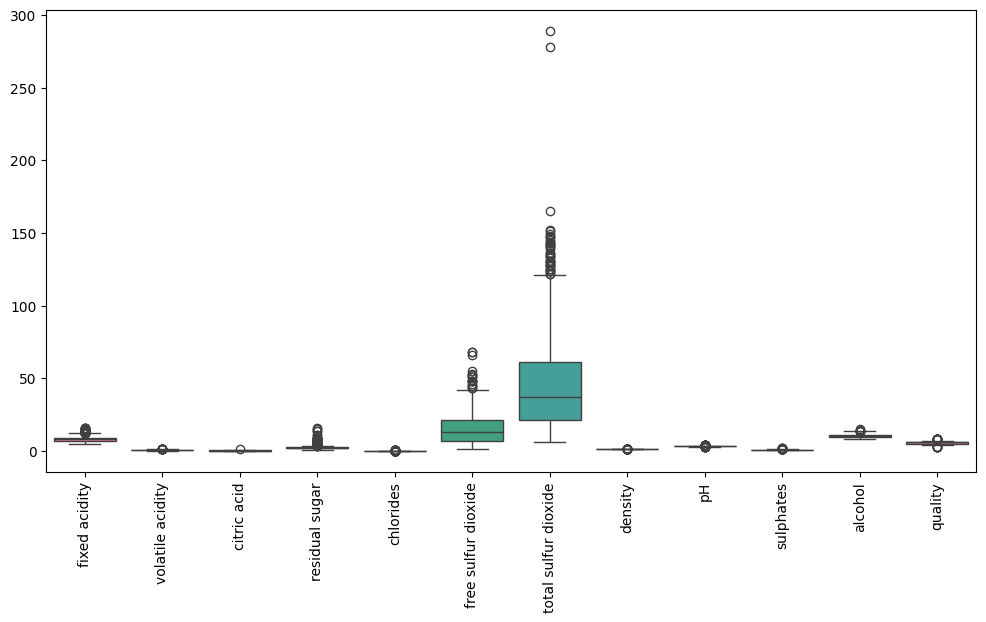

In [166]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show() # to check outliers we plotten it as xgboost is robust i.e not sensitive to outliers so we are not removing it and also there are only a few outliers the points which are beyond the  line of box plot called as whisker.

In [167]:
# The problem i faced here is our original data set values start from 3 but xgboost classifier need labels to start from 0 bcoz in multi class xgboost stores classes in a array and it thinks we already encoded array such that at 0 index we have class 0 and at 1 index we have class 1 so, now we have to convert it to this like class 3 to class 0 and later after prediction we convert it back to original values.
original_min=y.min() # here we are storing the original y min bcoz after y=y-y.min() the min of y changes and i becomes 0 but it is 3 originally so we need to store it.
y = y - y.min()  
clf=XGBClassifier(objective='multi:softprob',   # better than softmax
    num_class=len(np.unique(y)),
    n_estimators=500,             # more trees then better learning
    learning_rate=0.05,           # smaller step size then better accuracy
    max_depth=6,                  # deeper trees then easy to learn more complex model
    subsample=0.8,                # % of training data used for each tree
    colsample_bytree=0.8,         # % of features used for each tree
    eval_metric='mlogloss',
    random_state=42)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(clf, x, y, cv=skf)
print(f"Cross-validation accuracy: {cv_scores.mean():.4f}")
print(f"CV std deviation: {cv_scores.std():.4f}")


X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y) # with this we will have same percent of classes in both train and test same as the data set precentage eg: if class 7 are more in trainig but in test there are less then accuracy is reduced 
clf.fit(X_train,Y_train)

y_pred=clf.predict(X_test)

accuracy=accuracy_score(Y_test,y_pred)
                                                                                                                                                                                                                                                                                             

print("The accuracy of model is :",accuracy)
print("The classification report is :",classification_report(Y_test,y_pred))

print("Difference (Test - CV):", accuracy - cv_scores.mean())



Cross-validation accuracy: 0.6527
CV std deviation: 0.0381
The accuracy of model is : 0.7117903930131004
The classification report is :               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         7
           2       0.75      0.81      0.78        97
           3       0.69      0.73      0.71        92
           4       0.70      0.55      0.62        29
           5       0.50      0.33      0.40         3

    accuracy                           0.71       229
   macro avg       0.44      0.40      0.42       229
weighted avg       0.69      0.71      0.70       229

Difference (Test - CV): 0.05909752547307123


C:\Users\Jameel\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Jameel\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Jameel\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

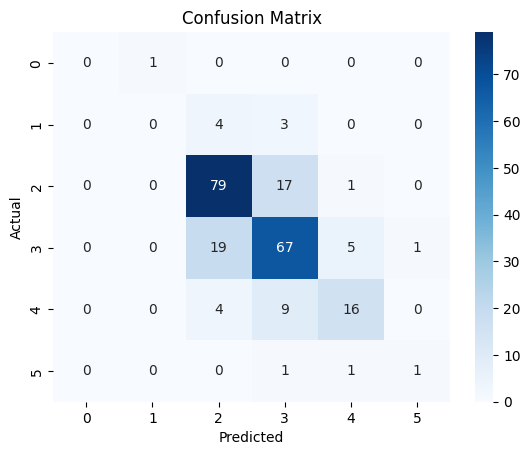

In [168]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

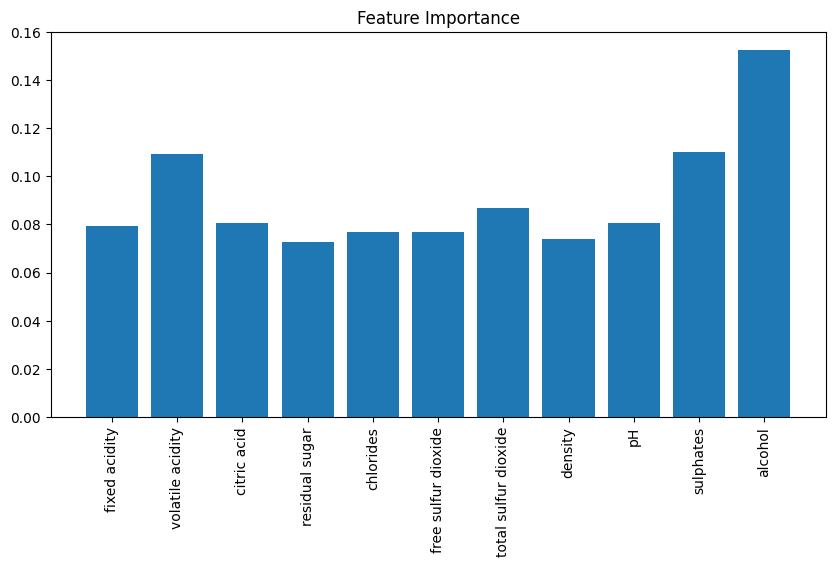

In [169]:
feature_names = df.drop(columns=["quality"]).columns

plt.figure(figsize=(10,5))
plt.bar(feature_names, clf.feature_importances_)
plt.xticks(rotation=90)
plt.title("Feature Importance")
plt.show()

In [170]:
import joblib

# Save model and original_min together
joblib.dump((clf, original_min), "wine_model.pkl") # we use it to save a trained machine learning model to a file and load it later without retraining .dump() means save data to a file
print("Model saved successfully!")

Model saved successfully!


In [171]:

clf.save_model("wine_model.json")